# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [84]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [85]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [86]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [87]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [88]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [89]:
print('plans', plans.info())# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
plans None


In [90]:
print('plans', users.info())# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
plans None


In [91]:
print('plans', usage.info())# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
plans None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [92]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [93]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Las columnas que tienen valores faltantes en users son:
  a) 'city' y 'churn date' (Alrededor de 11% y 88% respectivamente).
  b) 'date' en usage. 
- Indica qué harías: ¿imputar, eliminar, ignorar?
  a) Según se recomienda, para el caso de 'city', se pudiera investigar para imputarlos o dejarlos como nulos y ver si tuviera algún tipo de afectación en la contabilidad por ciudad.
  En cuanto a la proporción de nulos para 'usage', que es alrededor del 88%, se ignoraría el análisis, puesto que el volumen de datos faltantes es muy grande para hacer cualquier tipo de injerencia objetiva, o determinante para tendencias estadíticas o informativas. Esto también nos dice que haría falta revisar cómo es que se están registrando estas fechas, o si es porque no hay una tasa de abandono alta (ambas indicarías posibles rutas de acción para el negocio: fuese implementar mejores controles de registro, o revisar el éxito en el mantenimiento de los clientes).
  b) Considerando que el volumen de registros en usage es de 40,000, y los datos faltantes en 'date' son 50, se ignoraría puesto que es un número evidentemente mucho menor al 5% (que sería de unos 2,000 registros)
  En lo que se refiere a 'duration' y 'length', implmentaríamos una revisión, porque están entre el rango de investigación (cercano al 50%) y de eliminación o imputación. Probalmente, se explorarán los datos estadísiticos descriptivos para obtener visualización de sesgos, etc.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional en la siguiente línea.

In [94]:
print(users.describe())# explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` muestra datos estadísticos consistentes, sin grandes diferencias o variantes entre datos extremos, como el valor mínimo y el máximo, o los cuartiles.
- La columna `age`, por el contrario, muestra datos en la edad que incluyen 'sentinels' (-999), y que distan mucho de edades reales.  

In [95]:
print(usage.describe())# explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id ` no muestran mayor distorción numérica entre los cuartiles, la media, y los valores mínimos y máximos, considerando el número alto de registros.
- Las columnas 'duration' y 'length', sí muestran mayores rangos entre mínimos y máximos, que podría atribuirse a la naturaleza de las llamadas que realiza las personas (desde muy rápidas, hasta muy largas). Esto también podría indicar la existencia de outliers.

In [96]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` muestra una descripción que concuerda con la previa de registros nulos. Nos muestra que la mayor parte de los usuarios están en Bogotá, de entre 7 ciudades.
- La columna `plan` nos describe perfectamente el registro de los 2 planes iniciales, siendo el plan básico el que más popularidad muestra, con más del 50% de los usuarios registrados utilizándolo.

In [97]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` tiene 2 tipos de variables, siento 'text' la más frequente con poco más de la mitad de los registros.
  

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Se encontraron valores inválidos o sentinels en la columna 'age' de users.
- ¿Qué acción tomarías?
  Esto nos indica que probablemente habrá que calcular el total de registros con -999 y revisar si se eliminan o imputan.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [98]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce")
users['year'] = users['reg_date'].dt.year
users_year_counts = users['year'].value_counts().sort_index()
print(users_year_counts)
# completa el código

2022    1314
2023    1316
2024    1330
2026      40
Name: year, dtype: int64


En `reg_date`, podemos observar que hay 40 registros del año 2026, aunque en realidad solo debería haber hasta 2024, como se indica inicialmente. Luego entonces, podemos asumir que hay un error de registro en estos 40 datos que pueden sesgar el análisis.

In [99]:
# Revisar los años presentes en `date` de usage


In [100]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")
usage ['year'] = usage['date'].dt.year
usage_year_counts = usage['year'].value_counts().sort_index()
print(usage_year_counts)
# completa el código


2024.0    39950
Name: year, dtype: int64


En `date`, por el contrario, se observa que solo hay datos para el año 2024. También se nota un decimal. 


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Aparecen años imposibles, como el 2026. Al inicio, se menciona que el análisis considera los registros hasta 2024. Aparte de esto, en usage, el año parece tener decimales (2024.0)
  La diferencia entre más años previos a 2024 entre 'users' y 'usage' pudiera deberse a que en esta última están los años de registro, mientras que en 'usage' solo se analiza lo utilizado por los usuarios en 2024 sin importar su fecha de registro.
- ¿Qué harías con ellas?
  Para el caso de 'users', pudieran ignorarse como NA, o eliminarse los 40 registros con año 2026 ya que representan alrededor del 1% de los registros totales (por debajo del 5% recomendado para eliminar o ignorar)
  En cuanto a los decimales de 'usage', se recortarían los decimales.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [101]:
print("Valores -999 en age:", (users['age'] == -999).sum())
age_mediana = users[users['age'] != -999]['age'].median()
print(f"Mediana de age (sin -999): {age_mediana}")
users.loc[users['age'] == -999, 'age'] = age_mediana


Valores -999 en age: 55
Mediana de age (sin -999): 48.0


In [102]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].fillna(age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [103]:
# Reemplazar ? por NA en city
print("Valores ? en city:", (users['city'] == '?').sum())
users.loc[users['city'] == '?', 'city'] = pd.NA

# Verificar cambios
users['city'].describe()

Valores ? en city: 96


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [104]:
# Marcar fechas futuras como NA para reg_date
print("Fechas futuras iniciales:", (users['reg_date'].dt.year == 2026).sum())
users.loc[users['year'] == 2026, 'year'] = pd.NA
# Verificar cambios
print(users['year'].value_counts().sort_index())
print(f"\nRegistros NA en year: {users['year'].isna().sum()}")

Fechas futuras iniciales: 40
2022    1314
2023    1316
2024    1330
Name: year, dtype: int64

Registros NA en year: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [105]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_por_tipo_duration = usage['duration'].isna().groupby(usage['type']).sum()
print('Nulos por tipo duration:')
print(nulos_por_tipo_duration)

Nulos por tipo duration:
type
call        0
text    22076
Name: duration, dtype: int64


In [106]:
# Verificación MAR en usage (Missing At Random) para length
nulos_por_tipo_length = usage['length'].isna().groupby(usage['type']).sum()
print('Nulos por tipo length:')
print(nulos_por_tipo_length)

Nulos por tipo length:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se puede apreciar que para tipo de uso, su respectiva característica (duración de llamada, o largo del texto) muestra datos limpios. Por ejemplo, no hay datos nulos en la duración de llamadas, y tampoco hay datos nulos en lo largo del texto. Sin embargo, es interesante observar que sí hay información para la duración de un mensaje, o lo largo de una llamada. Esto se deduce porque se muestra que hay datos nulos de mensajes de poco más de 50% en la revisión de la duración, lo cual da a entender que el resto de las filas donde no existen datos nulos sí hay otro tipo de datos válidos. Lo mismo sucede con los mensajes de texto, donde hay datos nulos en poco menos del 50%, dando a pensar que hay datos en el porcentaje restante de filas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [107]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [108]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = 'user_id', how = 'left')
user_profile.head(15)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,2022,5.0,7.0,44.97
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,2022,3.0,5.0,28.39
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,2022,3.0,5.0,30.23
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,2022,5.0,5.0,28.85
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,2022,5.0,3.0,5.99


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [109]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [110]:
# Distribución porcentual del tipo de plan
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].value_counts(normalize=True).sort_values(ascending=False))

age   cant_mensajes  cant_llamadas  cant_minutos_llamada
47.0  6.0            4.0            20.92                   0.00050
55.0  8.0            0.0            0.00                    0.00050
38.0  6.0            5.0            35.22                   0.00025
18.0  3.0            5.0            18.91                   0.00025
      5.0            4.0            14.21                   0.00025
                                                             ...   
79.0  8.0            6.0            7.13                    0.00025
                     7.0            30.92                   0.00025
      9.0            0.0            0.00                    0.00025
                     2.0            6.66                    0.00025
      15.0           2.0            5.15                    0.00025
Length: 3997, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

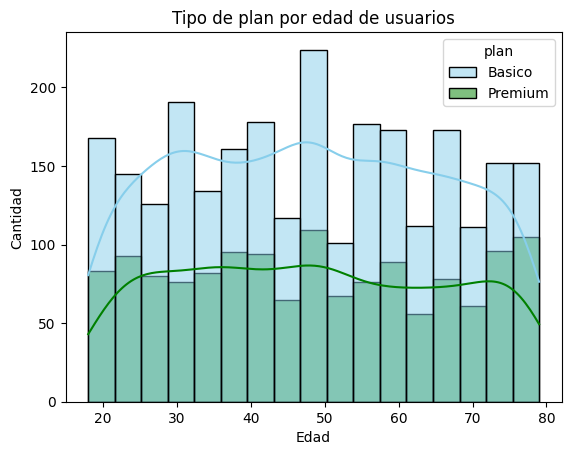

In [111]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age',hue='plan',palette=['skyblue','green'],kde=True)
plt.title('Tipo de plan por edad de usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad') 
plt.show()

💡Insights: 
- La distribución del tipo de planes por la edad se ve casi uniforme, especialmente para el plan premium.
  Sin embargo, para el plan básico, es notable un pico cerca de los 50. Este plan también muestra mayores variaciones entre las edades.
  Para el caso del Premium, es más estable, se notan menores cantidades en comparación con el básico, y menores repuntes entre edades.
  Se añadió una curva sobre el histograma para apreciar mejor la distribución y posibles altibajos a considerar. Esto ayudó a confirmar que el plan con mayor variabilidad entre edades es el básico, mientras que el premium es menos variable.

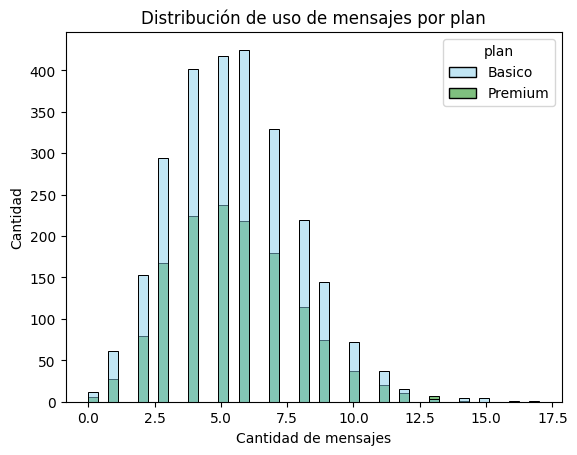

In [112]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes',hue='plan',palette=['skyblue','green'])
plt.title('Distribución de uso de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad') 
plt.show()


💡Insights: 
- En el histograma que revisa la cantidad de mensajes que usan por plan, se observa que sí hay una punta elevada considerablemente entre el rango 5 y 7.5 de cantidades de mensajes.

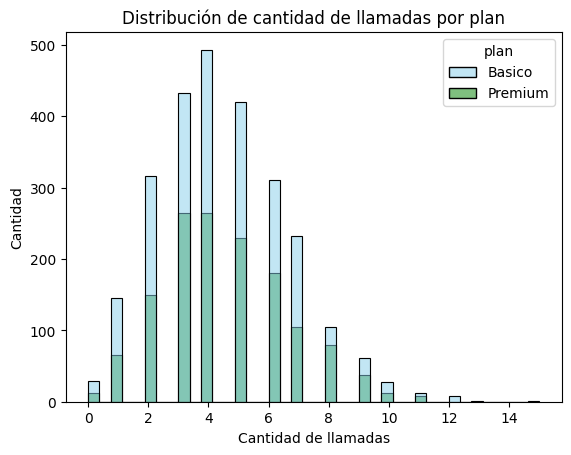

In [113]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas',hue='plan',palette=['skyblue','green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad') 
plt.show()


💡Insights: 
En el histograma que revisa la cantidad de llamadas que usan por plan, en este caso se observa un incremento considerable entre el rango 3 y 5.
Además se observa que ningún plan tiene una fuerte tendencia cantidad de llamadas alta.


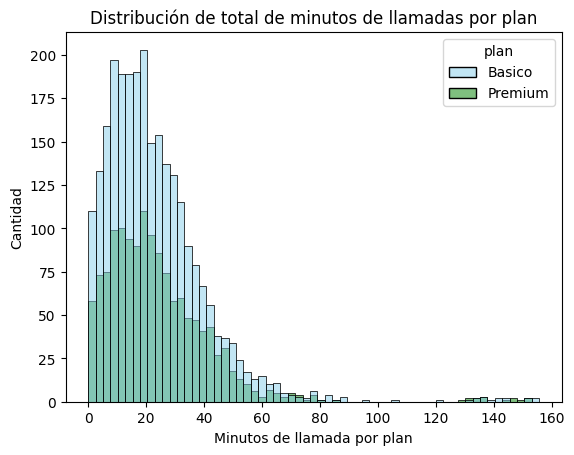

In [114]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada',hue='plan',palette=['skyblue','green'])
plt.title('Distribución de total de minutos de llamadas por plan')
plt.xlabel('Minutos de llamada por plan')
plt.ylabel('Cantidad') 
plt.show()


💡Insights: 
- En el histograma de total de minutos de llamadas por plan, se puede observar que la tendencia, además de ser consistente con una cantidad de llamdas bajas, muestra que estas son cortas; sin embargo, se observa que las llamadas cortas son mayores para el plan básico, en comparación de aquellas en el premium. Se alcanza a dibujar que hay un número más alto de llamadas largas con el plan premium, al extremo de los 140 minutos; se intentó colocar una curva de distribución pero cubría la visibilidad, y confirmaba que hay un sesgo hacia la derecha.

- Es de notar que en los tres histogramas se observa un mayor volumen de las tres variables (llamadas, mensajes y minutos), dentro del plan básico, al compararse con el plan premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

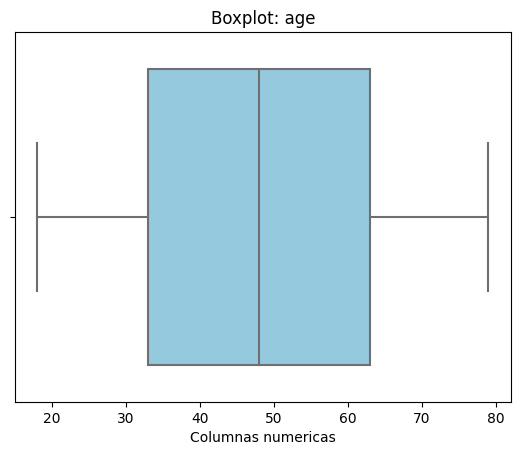

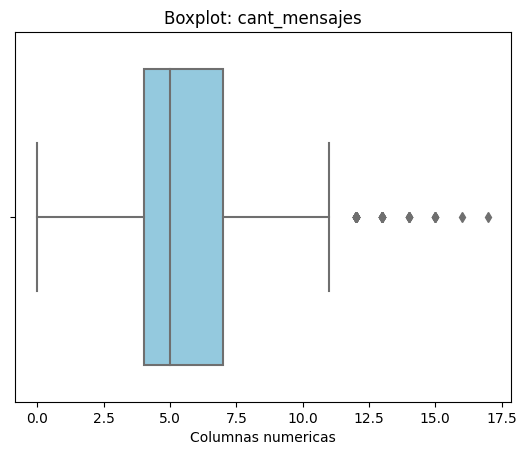

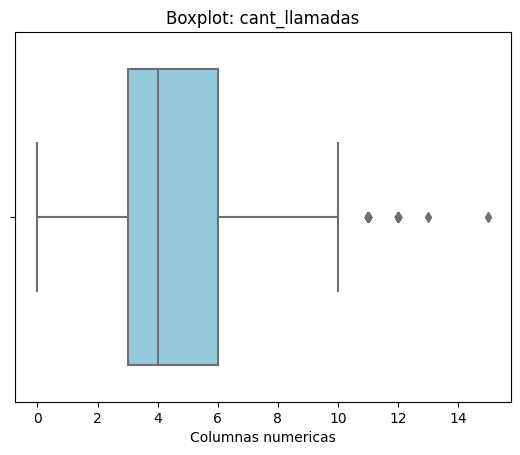

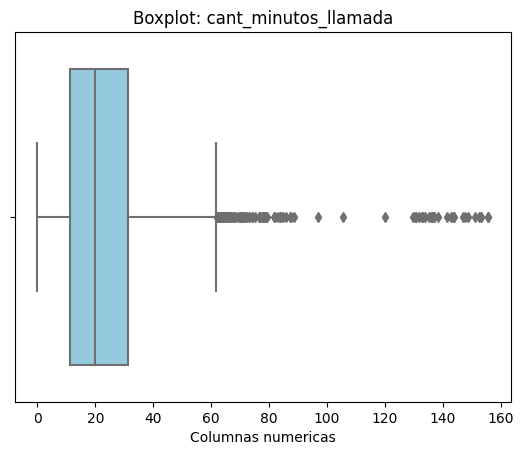

In [115]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Columnas numericas')
    plt.show()

💡Insights: 
- Age: en esta variable no se observan outliers en el boxplot.
- cant_mensajes: una vez graficando en caja la cantidad de mensajes, se observan datos 'outliers' con tendencia hacia la derecha, lo cual concuerda con las gráficas de barras anteriores.
- cant_llamadas: la cantidad de llamadas también muestra 'outliers' hacia el lado de las tendencias mayores.
- cant_minutos_llamada:en la gráfica de caja de los minutos de las llamadas, se notan 'outliers', pero también que estos parecieran estar segmentados en ciertos rangos (como el 60-80, o el del 140 en delante.
- A continuación se calculan los límites superiores, puesto que solo existen outliers con tendencia a los límites superiores de la gráfica de caja.

In [116]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes','cant_llamadas','cant_minutos_llamada']
Q1 = user_profile[columnas_limites].quantile(0.25)
Q3 = user_profile[columnas_limites].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print('\nLímites superiores')
print(upper)



Límites superiores
age                     108.0000
cant_mensajes            11.5000
cant_llamadas            10.5000
cant_minutos_llamada     61.8575
dtype: float64


In [117]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Los outliers se mantienen porque aunque representen casi el 50% más sobre el límite superior, esto indica que hay clientes que utilizan extra el plan, y puede traducirse a su vez en las ganancias que se generan para el negocio. Porque a pesar de que hay cierto límite de mensajes que cada plan incluye, los clientes están utilizando más y gastando más.
- cant_llamadas: mantener o no outliers, porqué? Lo mismo ocurre con la cantidad de llamadas, aunque el máximo está casi 50% más alto del límite superior, esto puede indicar mayor consumo de usuarios, y posterior análisis sobre considerar expandir planes para beneficiar a los usuarios.
- cant_minutos_llamada: mantener o no outliers, porqué? Sí hay 'outliers', con casi el doble del límite superior. Esto tambien dice que la gente usa mucho el tiempo en llamadas.
- En los tres casos se ha usado 'keep', ya que se consideran como extremos reales que pueden dar luz a segmentos del plan que dejan ganancias para la empresa y que hablan también de un comportamiento para la posible creación de planes más exclusivos, con más datos pero que compensen con el precio de la suscripción, o algún otro tipo de beneficio para los clientes también.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [118]:
# Crear columna grupo_uso
import numpy as np

user_profile['grupo_uso'] = np.where(

    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
    (user_profile['cant_llamadas'] <10) & (user_profile['cant_llamadas'] < 10),
    'Uso medio',
    'Alto uso'
    )
)
print(user_profile['grupo_uso'].value_counts())


Uso medio    3151
Bajo uso      778
Alto uso       71
Name: grupo_uso, dtype: int64


In [119]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Uso medio
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [120]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    
    (user_profile['age'] < 30),
    'Joven',
    np.where(
    (user_profile['age'] <60),
    'Adulto',
    'Adulto Mayor'
    )
)

print(user_profile['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [121]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Uso medio,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

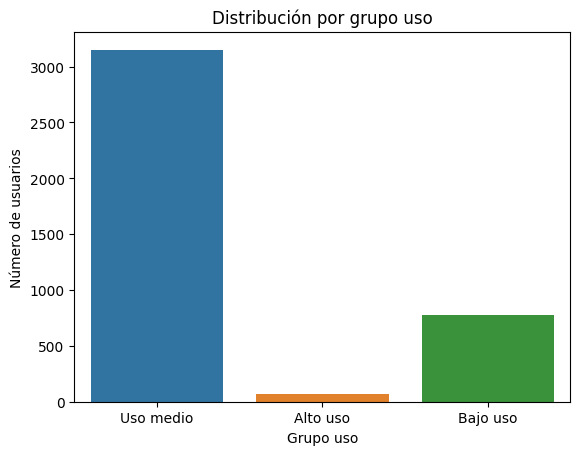

In [122]:
# Visualización de los segmentos por uso

sns.countplot(x=user_profile['grupo_uso'])
plt.title('Distribución por grupo uso')
plt.xlabel('Grupo uso')
plt.ylabel('Número de usuarios')
plt.show()



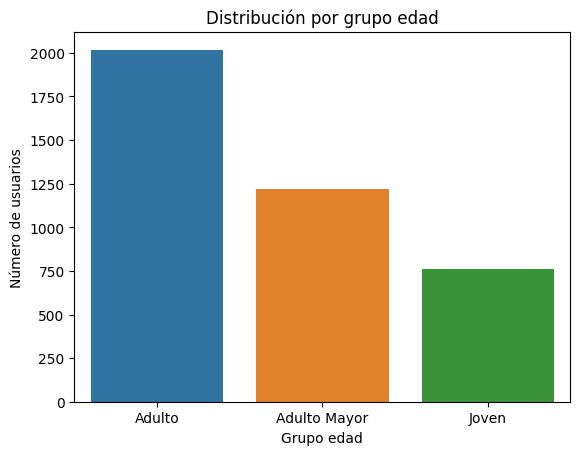

In [123]:
# Visualización de los segmentos por edad

sns.countplot(x=user_profile['grupo_edad'])
plt.title('Distribución por grupo edad')
plt.xlabel('Grupo edad')
plt.ylabel('Número de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

  Originalmente, en los datos se observó que existían problemas con el formato. Por ejemplo, había texto en columnas donde los datos deberían ser numéricos, como la columna de 'reg_date' en la serie de datos Plans.
  Además, había valores nulos en ambas series de datos. Los valores nulos se ignoraron, considerando que la proporción era, o muy pequeña, o muy grande para ser tomados en cuenta en el análisis estadístico y que tuvieran gran impacto en el mismo.
  Asímismo, los valores estadísticos, como la media o mediana, no notaron grandes variaciones, por lo que se tomó como una proporción distribuida para dichos indicadores.
  En cuanto a datos 'sentinels' o inválidos, se identificaron y posteriormente se imputó la mediana. Esto fue en la columna de 'age' de usuarios, con datos inexistentes.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

  Se identificaron los siguientes segmentos de clientes:
      1) Por uso: dentro de este segmento los clientes se clasificaron por uso medio, que es la gran mayoría de los usuarios; alto uso, con menos de 500 registros en el resultado; y por último, los de bajo uso, que tenían menos de 1000 registros.
    2) Por edad: Se identificaron tres grupos principales de edad y por cantidad. Se describen a continuación:
      a) Adultos mayores de 30 años y menores de 60, forman la mayoría de usuarios. En este grupo se nota la mayor cantidad de usuarios. Además, tomando consideración de los datos analizados inicialmente en los histogramas, que revisaron la cantidad de mensajes, llamadas, y minutos en llamadas por tipo de plan, notamos que aquí se encuentra además el grupo de edad que más consumo tiene, independientemente del plan que tengan. Especialmente en el rango que va de los 40 a los 50 años.
      b) Adultos mayores de 60 años: forman el grupo medio en cantidad de usarios. En cuanto al histograma de rango de edad, y de tipo de plan, muestran un patrón diversificado, pero que notamos tienen una cantidad considerable de alrededor de 1,250 usuarios. El tipo de plan, y consumo que podrían adquirir, muestran que su comportamiento es estable.
      c) Jóvenes menores de 30 años: aunque tienen el menor número de registro de usuarios, el tipo de plan y consumo es constante con el de los otros grupos. Luego entonces, muestran también potencial de mayor consumo en las 3 variantes que se analizan.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    Los tres segmentos son valiosos, pero definitivamente los de consumo medio y adultos son los más valiosos. Sin embargo, hay que considerar que todos los grupos y todos los planes exceden su consumo de mensajes, llamadas y minutos incluídos en los tipos de paquetes; además, los adultos entre los 40 y 70 años, muestran estabilidad en el tipo de plan y consumos, pero forman un grupo más pequeño de alto uso.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    Los patrones de uso extremo que se encontraron son con sesgo hacia la derecha. Esto quiere decir que en las tres variables, los usuarios, sin importar el plan o edad, excedían de lo incluído en los paquetes. Esto implica para el negocio más ganancia, sin importar el plan.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
    Basado en los segmentos y patrones detectados, se puede recomendar modificar, o crear, planes que atraigan a segmentos más jóvenes. Esto pudiera proyectar consumos fuera de los planes, siguiendo la tendencia de los consumidores actuales, a la vez que generaría un alza en el grupo de edad (que es el más pequeño).
    También pudieran emplearse paquetes que promovieran el alto uso, considerando que es el segmento más pequeño, considerablemente, y que hay clientes potenciales como los adultos, y los adultos mayores.
  
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En los datos se observó la existencia de problemas con el formato. Por ejemplo, había texto en columnas donde los datos deberían ser numéricos, como la columna de 'reg_date' en la serie de datos Plans. Además, había valores nulos en ambas series de datos. Los valores nulos se ignoraron, considerando que la proporción era, o muy pequeña, o muy grande para ser tomados en cuenta en el análisis estadístico y que tuvieran gran impacto en el mismo. Asímismo, los valores estadísticos, como la media o mediana, no notaron grandes variaciones, por lo que se tomó como una proporción distribuida para dichos indicadores. En cuanto a datos 'sentinels' o inválidos, se identificaron y posteriormente se imputó la mediana. Esto fue en la columna de 'age' de usuarios, con datos inexistentes.

a) Tipo de datos importados incorrecto, texto en vez de número (object en vez de int64 o float64)
b) Existencia de sentinels (e.g. -999)
c) Existencia de valores nulos.

🔍 **Segmentos por Edad**
Se identificaron tres grupos principales de edad y por cantidad. Se describen a continuación:

1) Segmento adulto: mayores a 30 y menores a 60
      Conforman la mayoría de usuarios. En este grupo se nota la mayor cantidad de usuarios. Además, tomando consideración de los datos analizados inicialmente en los histogramas, que revisaron la cantidad de mensajes, llamadas, y minutos en llamadas por tipo de plan, notamos que aquí se encuentra además el grupo de edad que más consumo tiene, independientemente del plan que tengan. Especialmente en el rango que va de los 40 a los 50 años.

2) Segmento adulto mayor: mayores de 60
      Forman el grupo medio en cantidad de usarios. En cuanto al histograma de rango de edad, y de tipo de plan, muestran un patrón diversificado, pero que notamos tienen una cantidad considerable de alrededor de 1,250 usuarios. El tipo de plan, y consumo que podrían adquirir, muestran que su comportamiento es estable.

3) Segmento joven: menores de 30:
      Aunque tienen el menor número de registro de usuarios, el tipo de plan y consumo es constante con el de los otros grupos. Luego entonces, muestran también potencial de mayor consumo en las 3 variantes que se analizan.


📊 **Segmentos por Nivel de Uso**
Dentro de este segmento los clientes se clasificaron por uso medio, que es la gran mayoría de los usuarios; alto uso, con menos de 500 registros en el resultado; y por último, los de bajo uso, que tenían menos de 1000 registros.

1) Segmento de bajo uso: <5 (llamadas, mensajes),
2) Segmento de uso medio: >5 y < 10 (llamadas, mensajes),
3) Segmento de alto uso: > 10 (llamadas, mensajes).

➡️ Esto sugiere que los tres segmentos son valiosos, pero definitivamente los de consumo medio y adultos son los más valiosos. Sin embargo, hay que considerar que todos los grupos y todos los planes exceden su consumo de mensajes, llamadas y minutos incluídos en los tipos de paquetes; además, los adultos entre los 40 y 70 años, muestran estabilidad en el tipo de plan y consumos, pero forman un grupo más pequeño de alto uso.

💡 **Recomendaciones**
- Se recomienda que se creen, o modifiquen, planes más atractivos para jóvenes que pudiera resultar en consumo mayor; también lo mismo para adultos mayores.
- Se recomienda que se dé más enfoque l grupo de adultos, que parecen tener la mayor cantidad de ambos planes, pero también de consumo fuera de lo incluídos en los mismos. Tal vez algún tipo de recompensa, o la ampliación de beneficios puesto que los outliers indican que hay un gran rango de consumo fuera de lo que se incluye en el paquete, sin importarlo. Luego entonces, se puede crear la idea en el cliente de que está obteniendo más, sin una pérdidad considerable para la empresa. Esto pudiera generar lealtad, o atracción a nuevos clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`